# Semana 1: Tarea

**Tópicos de Finanzas Avanzadas (ECON-421, UPAO 2026-20)**
**Entrega: hasta el lunes de la semana siguiente, vía `git commit` + `push` en tu fork** (`01_fundamentos_valor/clase01_tarea.ipynb`)

Completa las celdas marcadas con `# TU CÓDIGO AQUÍ` y las celdas de texto marcadas con .
El notebook debe **correr de inicio a fin** sin errores (`Kernel  Restart & Run All`).

## Parte 1, Diagnóstico del entorno (2 pts)

Ejecuta la celda. Si tu instalación quedó bien, imprime versiones y tu usuario de GitHub.

In [1]:
import sys, numpy as np, pandas as pd

print("Python:", sys.version.split()[0])
print("numpy :", np.__version__)
print("pandas:", pd.__version__)

MI_USUARIO_GITHUB = "ClaudioL24"   #  escribe tu usuario entre comillas
print("GitHub:", MI_USUARIO_GITHUB or " falta completar")

Python: 3.14.7
numpy : 2.5.2
pandas: 3.0.5
GitHub: ClaudioL24


## Parte 2, La función `tir()` (5 pts)

Copia tus funciones `vp()` y `vpn()` de la práctica y programa `tir()`.
Comprueba con el ejemplo de clase: invertir 100 y recibir (30, 40, 60) debe dar **TIR ≈ 12.7%**.

In [2]:
def vp(flujos, r):
    # TU CÓDIGO AQUÍ
    return sum(cf / (1 + r) ** t for t, cf in enumerate(flujos, start=1))

def vpn(cf0, flujos, r):
    # TU CÓDIGO AQUÍ
    return -cf0 + vp(flujos, r)

def tir(cf0, flujos):
    # TU CÓDIGO AQUÍ (pista: numpy.roots, como en la práctica)
    coef = list(reversed(flujos)) + [-cf0]
    raices = np.roots(coef)
    reales = raices[np.isreal(raices)].real
    candidatas = [1 / x - 1 for x in reales if x > 0]
    return min([r for r in candidatas if r > -1], key=abs)

# Comprobación
# print(f"TIR = {tir(100, [30, 40, 60]):.2%}")   # descomenta: debe dar ≈ 12.7%

In [3]:
print(f"TIR = {tir(100, [30, 40, 60]):.2%}")

TIR = 12.71%


## Parte 3, Valorar un bono simple (5 pts)

Un bono paga cupones de 80 al final de cada uno de los próximos 4 años y devuelve el principal de 1000 junto
con el último cupón (flujos: 80, 80, 80, 1080).

Usa tu función `vp()` para valorarlo a tres tasas: **6%, 8% y 10%**.

In [4]:
flujos_bono = [80, 80, 80, 1080]

for r in [0.06, 0.08, 0.10]:
    # TU CÓDIGO AQUÍ: imprime el precio del bono a cada tasa
    precio = vp(flujos_bono, r)
    print(f"Precio del bono a {r:.0%} = {precio:.2f}")

Precio del bono a 6% = 1069.30
Precio del bono a 8% = 1000.00
Precio del bono a 10% = 936.60


 **Comenta:** ¿qué pasa con el precio del bono cuando sube la tasa? ¿A qué tasa el bono vale exactamente 1000 y por qué?

*A medida que sube la tasa el precio del bono disminuye. La tasa en la que el bono vale exactamente 1000 es 8%, y es porque la tasa de descuento, r=8%, coincide con la tasa cupón. Dependiendo de cuanto valoras tu dinero a día de hoy, estas dispuesto a pagar más o menos por este. *

## Parte 4, Datos reales (4 pts)

Descarga con `yfinance` el precio de **otra** acción peruana o latinoamericana (p. ej. `SCCO`, `BVN`, `IFS`)
desde 2018 y grafícala.

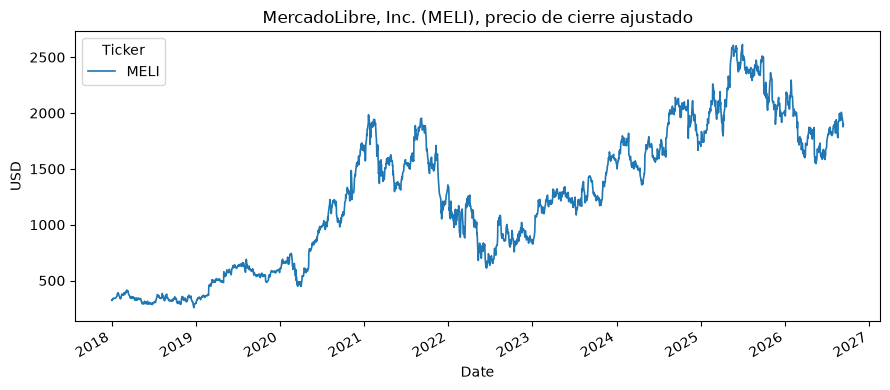

Ticker             MELI
Date                   
2026-09-04  1978.359985
2026-09-08  1926.250000
2026-09-09  1876.329956
2026-09-10  1906.239990
2026-09-11  1897.369995


In [5]:
import yfinance as yf
import matplotlib.pyplot as plt

# TU CÓDIGO AQUÍ: descarga y grafica
import yfinance as yf

bap = yf.download("MELI", start="2018-01-01", auto_adjust=True, progress=False)["Close"]

fig, ax = plt.subplots(figsize=(9, 4))
bap.plot(ax=ax, lw=1.2)
ax.set_title("MercadoLibre, Inc. (MELI), precio de cierre ajustado")
ax.set_ylabel("USD")
plt.tight_layout()
plt.show()

print(bap.tail())

 **Reflexiona (estilo CFA):** para estimar el valor intrínseco de la empresa que elegiste,
¿qué necesitarías proyectar y qué tasa usarías para descontar? Menciona al menos 4 elementos.

Para estimar el valor intrínseco de la empresa, que se necesitaria para proyectar y tasas para descontar se necesitarian:
1. Revenue y tasa de crecimiento: Mediante una proyección tomando el registro histórico de las acciones y las expectativas de crecimiento / expansion regional.
2. Márgenes operativos: Tener en cuenta el porcentaje y los márgenes de ganancia, cuanto dinero invertido se transforma en utilidad y tener en cuenta donde estan los costos más altos.
3. Tasa riesgo país: Debido a que opera en latinoamérica se tiene que ajustar un prima de riesgo debido a la inestabilidad política del continente y el riesgo cambiario.
4. Estructura del capital: Observando la relacion deuda/capital, y la expectativa a la que la empresa quiere llegar en esta proporción, podría afectar la tasa de descuento.

La tasa que se utilizariía para descontar esta relacionado al tema de la semana02: WACC, no se utiliza una tasa igual a los bonos, sino que se calcula un costo del capital en función al CAPM, costo de la deuda, tasa impositiva, el valor de mercado y de la deuda.

## Parte 5, Ítems tipo CFA (4 pts)

Responde en la celda de texto al final, justificando en una línea cada respuesta.

**1.** Un analista estima el valor intrínseco de una acción en S/ 25.40; la acción cotiza a S/ 22.00.
La diferencia de S/ 3.40 representa *más probablemente*:
&nbsp;&nbsp;A. el mispricing verdadero.
&nbsp;&nbsp;B. el error de estimación.
&nbsp;&nbsp;C. la suma del mispricing verdadero y el error de estimación.

**2.** El valor intrínseco de un activo se define *mejor* como el valor:
&nbsp;&nbsp;A. de liquidación de la empresa.
&nbsp;&nbsp;B. que le asigna un inversionista con entendimiento completo de las características del activo.
&nbsp;&nbsp;C. de mercado menos una prima de control.

**3.** Un proyecto tiene VPN = 0 cuando se descuenta al 14%. Si la tasa exigida es 11%, el VPN es *más probablemente*:
&nbsp;&nbsp;A. negativo.
&nbsp;&nbsp;B. cero.
&nbsp;&nbsp;C. positivo.

**4.** Una empresa reinvierte utilidades creciendo, pero su ROIC es menor que su WACC. El valor para el accionista *más probablemente*:
&nbsp;&nbsp;A. aumenta, porque la empresa crece.
&nbsp;&nbsp;B. disminuye, porque cada sol reinvertido rinde menos que su costo.
&nbsp;&nbsp;C. no cambia, porque el crecimiento compensa el menor retorno.

 **Respuestas:**

1. C
2. B
3. C
4. B

---
**Recuerda:** `Kernel  Restart & Run All` antes de entregar, y luego:

```bash
git add 01_fundamentos_valor/clase01_tarea.ipynb
git commit -m "Semana 1: tarea"
git push
```